In [2]:
import os
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from PIL import Image

In [3]:
# C'est le point le plus important du briefing !
# Les classes ne sont PAS dans des dossiers séparés.

def get_label(filepath):
    filename = os.path.basename(filepath).lower()
    if 'bacteria' in filename:
        return 'PNEUMONIA_BACTERIA'
    elif 'virus' in filename:
        return 'PNEUMONIA_VIRUS'
    else:
        return 'NORMAL'

# Construire la liste de tous les fichiers + leurs labels
def load_file_list(split_dir):
    """split_dir = chemin vers train/, val/, ou test/"""
    files = []
    for classe in ['NORMAL', 'PNEUMONIA']:
        folder = os.path.join(split_dir, classe)
        for fname in os.listdir(folder):
            if fname.lower().endswith(('.jpeg', '.jpg', '.png')):
                fpath = os.path.join(folder, fname)
                label = get_label(fpath)
                files.append((fpath, label))
    return files

DATA_DIR = 'data/chest_xray'

train_files = load_file_list(os.path.join(DATA_DIR, 'train'))
val_files   = load_file_list(os.path.join(DATA_DIR, 'val'))
test_files  = load_file_list(os.path.join(DATA_DIR, 'test'))

print(f"Train : {len(train_files)} images")
print(f"Val   : {len(val_files)} images")
print(f"Test  : {len(test_files)} images")

Train : 5216 images
Val   : 16 images
Test  : 624 images


Distribution dans le train :
  NORMAL: 1341 images
  PNEUMONIA_BACTERIA: 2530 images
  PNEUMONIA_VIRUS: 1345 images


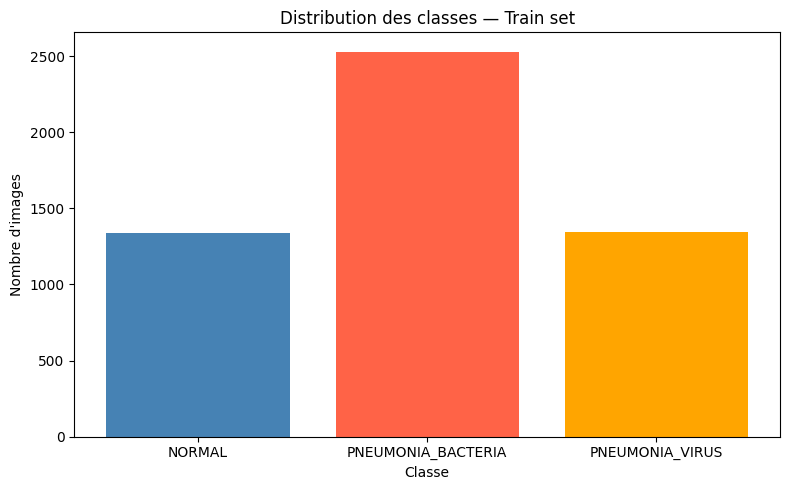

In [4]:
# Compter les classes dans le train
labels_train = [label for _, label in train_files]
distribution = Counter(labels_train)

print("Distribution dans le train :")
for cls, count in distribution.items():
    print(f"  {cls}: {count} images")

# Graphique en barres
plt.figure(figsize=(8, 5))
plt.bar(distribution.keys(), distribution.values(), color=['steelblue', 'tomato', 'orange'])
plt.title("Distribution des classes — Train set")
plt.ylabel("Nombre d'images")
plt.xlabel("Classe")
plt.tight_layout()
plt.savefig("distribution.png")
plt.show()


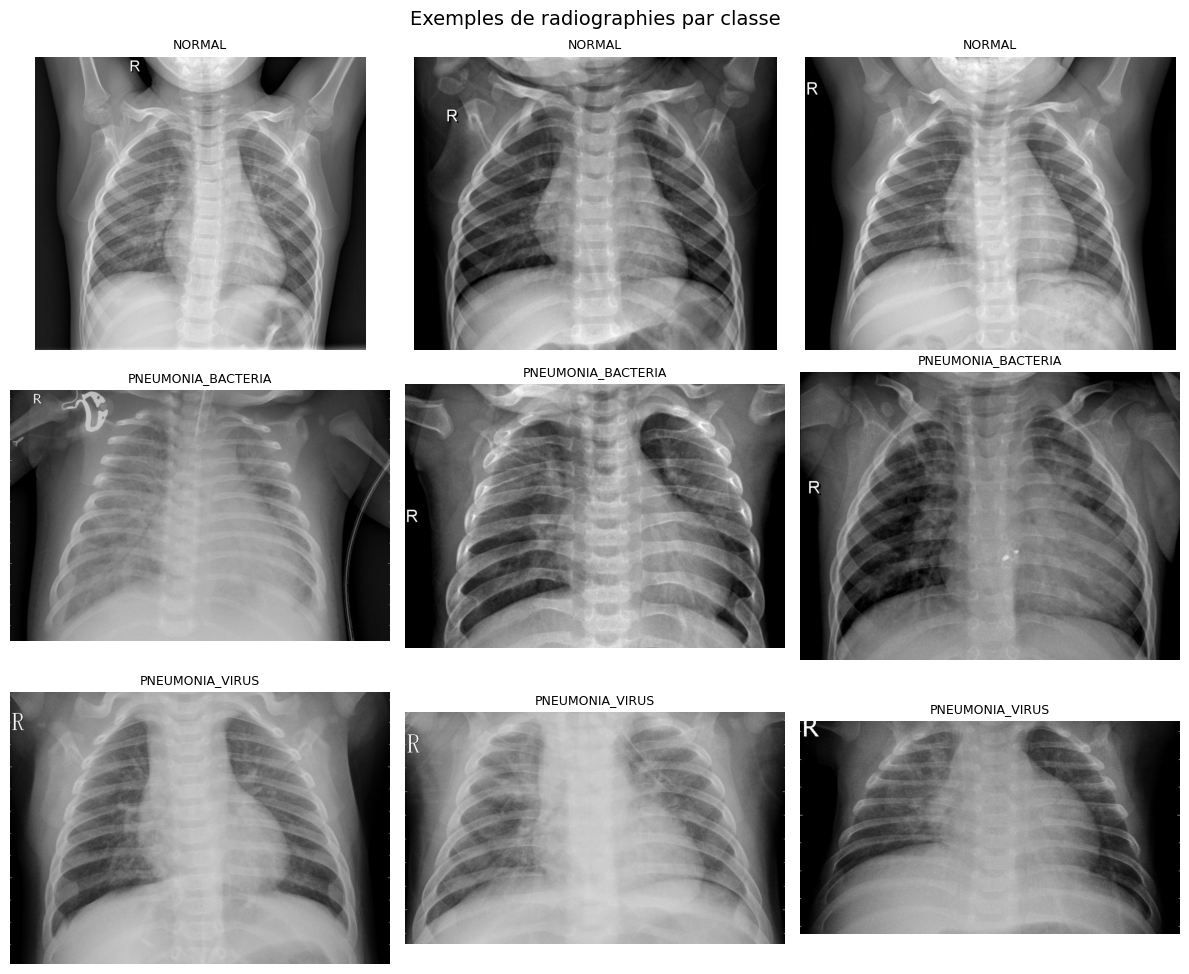

In [5]:
def show_examples(file_list, n_per_class=3):
    classes = ['NORMAL', 'PNEUMONIA_BACTERIA', 'PNEUMONIA_VIRUS']
    fig, axes = plt.subplots(len(classes), n_per_class, figsize=(12, 10))
    
    for row, cls in enumerate(classes):
        # Prendre n exemples de cette classe
        samples = [(f, l) for f, l in file_list if l == cls][:n_per_class]
        for col, (fpath, label) in enumerate(samples):
            img = Image.open(fpath).convert('RGB')
            axes[row, col].imshow(img, cmap='gray')
            axes[row, col].set_title(label, fontsize=9)
            axes[row, col].axis('off')
    
    plt.suptitle("Exemples de radiographies par classe", fontsize=14)
    plt.tight_layout()
    plt.savefig("exemples_radios.png")
    plt.show()

show_examples(train_files)


In [6]:
# Vérifier la taille des images (elles varient dans ce dataset)
sizes = []
for fpath, _ in train_files[:100]:  # Juste les 100 premières pour aller vite
    img = Image.open(fpath)
    sizes.append(img.size)

widths  = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

print(f"Largeur  : min={min(widths)}  max={max(widths)}  moy={np.mean(widths):.0f}")
print(f"Hauteur  : min={min(heights)} max={max(heights)} moy={np.mean(heights):.0f}")
print("\n→ Toutes les images seront redimensionnées en 224×224 lors du DataLoader.")

Largeur  : min=994  max=2396  moy=1679
Hauteur  : min=747 max=2025 moy=1332

→ Toutes les images seront redimensionnées en 224×224 lors du DataLoader.
